<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Sentiment Analysis - Mental Health</center></h1>


#

## Data Description

The target dataset was retrieved from Kaggle at https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health.

### Content

This comprehensive dataset is a meticulously curated collection of mental health statuses tagged from various statements. The dataset amalgamates raw data from multiple sources, cleaned and compiled to create a robust resource for developing chatbots and performing sentiment analysis.

Data Overview:
The dataset consists of statements tagged with one of the following seven mental health statuses:
* Normal
* Depression
* Suicidal
* Anxiety
* Stress
* Bi-Polar
* Personality Disorder

The data is sourced from diverse platforms including social media posts, Reddit posts, Twitter posts, and more.

### Objective

This dataset is ideal for training machine learning models aimed at understanding and predicting mental health conditions based on textual data.

Deep learning methods, supported by NLP embedding approaches, will be applied, evaluated, compared and regularized to achieve a meaningful mental health status classification.

Resulting models could be used in various applications such as:

* Chatbot development for mental health support.
* Sentiment analysis to gauge mental health trends.
* Academic research on mental health patterns.

## Data import and overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Layer, layers
from tensorflow.keras.layers import TextVectorization, Input, SimpleRNN, Embedding, LSTM, GRU, BatchNormalization, Dropout
import tensorflow_hub as hub
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from keras import initializers
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

C:\Users\conta\miniconda3\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

np.random.seed(42)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\conta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\conta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\conta\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\conta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\conta\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
data = pd.read_csv('data/Combined Data.csv')

display(data.head())

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
data.shape

(53043, 3)

# EDA
## Check ID Uniqueness

In [5]:
all(data['Unnamed: 0'] == data.index)

True

The `Unnamed: 0` column is just a duplicate of the index and thus does not contain any valuable information: it can be dropped.

In [6]:
data.drop(columns='Unnamed: 0', inplace=True)

## Handle Missing Data

In [7]:
data[data['status'].isna()]

,statement,status


In [8]:
data[data['statement'].isna()]

,statement,status
293,NaN,Anxiety
572,NaN,Anxiety
595,NaN,Anxiety
1539,NaN,Normal
2448,NaN,Normal
...,...,...
52838,NaN,Anxiety
52870,NaN,Anxiety
52936,NaN,Anxiety
53010,NaN,Anxiety


There are 362 records with missing statement: let's drop them.

In [9]:
data.dropna(subset='statement', inplace=True)

data

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


## Check for Duplicates

In [10]:
data[data[['statement', 'status']].duplicated()]

,statement,status
97,"""No regrets or grudges/angry at things that ha...",Anxiety
138,but my heart is still restless even though my ...,Anxiety
167,I want to exhale the restlessness in my chest ...,Anxiety
228,Do not compare yourself to others. Envy only m...,Anxiety
244,"people seem calm, happy like there's no proble...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


There are 1588 records which are duplicates of the same pair `(statement, status)`: let's drop them.

In [11]:
data.drop_duplicates(subset=['statement', 'status'], inplace=True)

data

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
52835,Anxiety cause faintness when standing up ? As ...,Anxiety
52836,anxiety heart symptom does anyone else have th...,Anxiety
52837,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety
52839,fomo from things i’m not involved in does anyo...,Anxiety


Let's now investigate for duplicated statements.

In [12]:
data.shape[0] == len(data['statement'].unique())

False

In [13]:
dup_statements = data[data[['statement']].duplicated()]

dup_statements

,statement,status
8130,"All this work, all this pressure that everyone...",Depression
10440,Recently I have started this internship and mo...,Depression
11969,I am a drug abuser (benzos and meth mostly) an...,Depression
12304,So...HI I am Emma a young trans woman from ger...,Depression
12402,I have been at home the past year... quite lit...,Depression
20464,#NAME?,Suicidal
22644,My twin betrayed me and it cost me some of my ...,Depression
23411,"Hi,I am a 28 year old (she will of a) man from...",Suicidal
25062,we are able to fly space ships and control sat...,Depression
26769,Its been a month since my partner of 10 years ...,Suicidal


In [14]:
len(dup_statements)

20

A few more records have a duplicated statement with a different status: their amount is basically insignificant (20) so let's just drop the duplicates. In addition, let's remove the row with the faulty statement '#NAME?'.

In [15]:
data.drop_duplicates(subset='statement', inplace=True)

In [16]:
data = data[data['statement'] != '#NAME?']

In [17]:
data = data.reset_index()

data

,index,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
51067,52835,Anxiety cause faintness when standing up ? As ...,Anxiety
51068,52836,anxiety heart symptom does anyone else have th...,Anxiety
51069,52837,Travel Anxiety Hi all! Long time anxiety suffe...,Anxiety
51070,52839,fomo from things i’m not involved in does anyo...,Anxiety


We ended up with a dataset characterized by 51072 unique labeled statements.

## Features Distribution

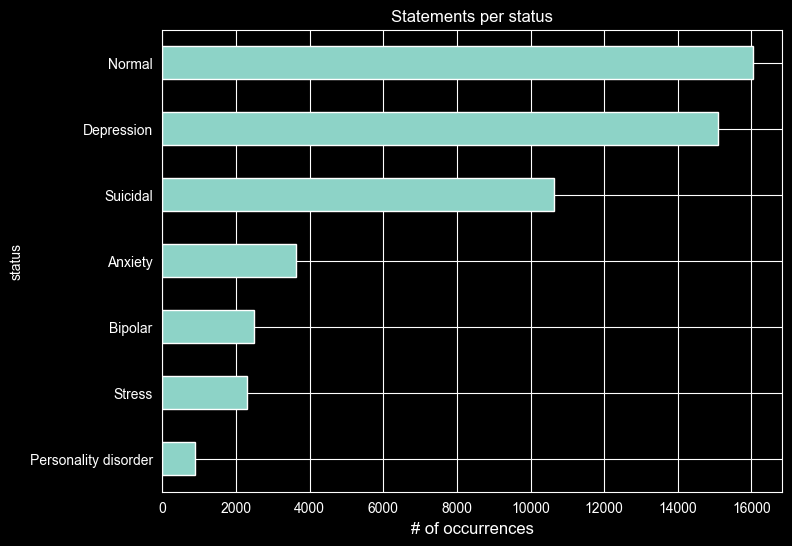

In [18]:
fig = plt.figure(figsize=(8,6))

data.groupby(['status']).statement.count().sort_values().plot.barh(ylim=0, title= 'Statements per status')

plt.xlabel('# of occurrences', fontsize = 12);

In [19]:
status_value_counts = data['status'].value_counts().to_frame()

status_value_counts

,count
status,
Normal,16039
Depression,15086
Suicidal,10641
Anxiety,3617
Bipolar,2501
Stress,2293
Personality disorder,895


In [20]:
num_classes = len(status_value_counts)

num_classes

7

We are dealing with a pretty unbalanced dataset, with just ~900 records (1.7%) labeled with the minority status (`Personality disorder`). Still, data could be enough to ensure a proper classification by means of adequate modeling, especially with label stratification applied to train/validation/test data split.

## Data Cleaning

Now we will focus on preprocessing the raw statements. This step is important because raw text without preprocessing is highly unstructured and contains redundant and often problematic information. It contains tons of noise that should be removed.

Text data will be cleaned by following the steps below.

*   Remove punctuation
*   Remove stopwords
*   Tokenization - converting a sentence into list of words
*   Lemmatization and stemming - tranforming any form of a word to its root word

Stopwords removal and lemmatization will be done with the support of the Natural Language Toolkit (NLTK) suite.

In [21]:
regular_punct = list(string.punctuation)

def remove_punctuation(text):
    text = str(text)

    for punc in regular_punct:
        if punc in text:
            text = text.replace(punc, ' ')

    return ' '.join(text.split()).lower()

data['statement'] = data['statement'].apply(remove_punctuation)

In [22]:
en_stops = set(stopwords.words('english'))

def remove_stopwords(text):
    text = text.split()
    text = ' '.join([word for word in text if not word in en_stops])

    return text

data['statement'] = data['statement'].apply(remove_stopwords)

In [23]:
data['statement'] = data['statement'].apply(word_tokenize)

In [24]:
lem = WordNetLemmatizer()

def lemma_wordnet(words):
    return [lem.lemmatize(word) for word in words]

data['statement'] = data['statement'].apply(lemma_wordnet)

In [25]:
data['statement'] = data['statement'].apply(lambda x: ' '.join(x))

In [26]:
data

,index,statement,status
0,0,oh gosh,Anxiety
1,1,trouble sleeping confused mind restless heart ...,Anxiety
2,2,wrong back dear forward doubt stay restless re...,Anxiety
3,3,shifted focus something else still worried,Anxiety
4,4,restless restless month boy mean,Anxiety
...,...,...,...
51067,52835,anxiety cause faintness standing title anxiety...,Anxiety
51068,52836,anxiety heart symptom anyone else something si...,Anxiety
51069,52837,travel anxiety hi long time anxiety sufferer f...,Anxiety
51070,52839,fomo thing i ’ m involved anyone else get rece...,Anxiety


## Hyperparameter estimation

The models I'm going to use require to define 2 important hyperparameters:
* statement length, for a consistent preprocessing of each record via padding/truncation;
* vocabulary size, to define a dimension of possible Embedding layers.

Let's estimate them by analyzing the data.

In [27]:
data['statement length'] = data['statement'].apply(lambda x: len(str(x).split()))

data.describe()

,index,statement length
count,51072.000000,51072.000000
mean,25799.303748,52.965950
std,14978.957738,77.917861
min,0.000000,0.000000
25%,12863.750000,8.000000
50%,25647.500000,29.000000
75%,38670.250000,69.000000
max,52840.000000,5040.000000


We can notice how the 3rd quartile shows a statement length of 69: let's consider 70 as statement length.

In [28]:
vocabulary = {}

for statement in data['statement']:
    for word in statement.split():
        vocabulary[word] = None

len(vocabulary)

55633

There are ~56k unique words in the data - let's consider a vocabulary size of 50k, assuming that the remainder of less frequent words can be neglected.

## Features Encoding

### One-Hot Encoding of the Categorical Target

In [29]:
label_encoder = OneHotEncoder(sparse_output=False)
y = label_encoder.fit_transform(data['status'].to_frame())

y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(51072, 7))

# Modeling
## Train/Validation/Test Split
I'll stratify train, validation and test set with respect to the target, so as to get the same labels distribution in all datasets.

We will use 90% of the entire dataset for training, and 10% of it for testing purposes. 20% of the training data is then extracted as validation set.

All NNs will be compiled with categorical cross-entropy as loss function, compatible with multi-label classification. Adam will be used as optimizer and accuracy as validation metric.

Our reference metric in the classification report will be the weighted F1 score, which is well-descriptive with imbalanced classification tasks.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    data['statement'].to_numpy(), y, test_size = 0.1, random_state=42, shuffle=True, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size = 0.2, random_state=42, shuffle=True, stratify=y_train
)

X_train.shape, X_val.shape, X_test.shape

((36771,), (9193,), (5108,))

Let's define batch size and number of epochs for NN training. Let's consider a low number of epochs for fast training in order to perform model selection, then we'll apply a higher number of iterations to train the final selected model.

In [31]:
batch_size = 64
n_epochs = 5

Helper function to display train/validation trends for loss and accuracy through NN training epochs.

In [32]:
def display_metrics(history):
    n = len(history.history['loss'])

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(range(n), (history.history['loss']),'r', label='Train Loss')
    ax.plot(range(n), (history.history['val_loss']),'b', label='Validation Loss')
    ax.legend()
    ax.set_title('Loss over iterations')

    ax = fig.add_subplot(1, 2, 2)
    ax.plot(range(n), (history.history['accuracy']),'r', label='Train Accuracy')
    ax.plot(range(n), (history.history['val_accuracy']),'b', label='Validation Accuracy')
    ax.legend(loc='lower right')

    ax.set_title('Accuracy over iterations')

## Pre-Trained Models

### Model #1 - Simple Neural Network with Universal Sentence Encoder

As first model we'll take into account a simple NN whose core is given by a pre-trained encoding layer.

The `hub.KerasLayer` wraps a SavedModel (or a legacy TF1 Hub format) as a Keras Layer. The `universal-sentence-encoder` is an encoder of greater-than-word length text trained on a variety of data. It can be used for text classification, semantic similarity, clustering, and other natural language tasks.

We can train a simple text classifier on top of any TF-Hub module that can embed sentences. The Universal Sentence Encoder was partially trained with custom text classification tasks in mind. These kinds of classifiers can be trained to perform a wide variety of classification tasks often with a very small amount of labeled examples.

The encoder layer is wrapped via subclassing, and the model is built via the Functional API Keras methodology. It consists of:
* Input layer
* Universal Sentence Encoder Layer (pre-trained)
* Output Dense layer with softmax activation



In [33]:
class EncoderLayer(Layer):
    def call(self, x):
        return hub.KerasLayer('https://tfhub.dev/google/universal-sentence-encoder/4',
               input_shape=[],
               dtype = tf.string,
               trainable=False,
               name='pretrained')(x)

input_text = Input(shape=[], dtype=tf.string)
encoder_layer = EncoderLayer()(input_text)
output_layer = layers.Dense(num_classes, activation='softmax')(encoder_layer)
model = Model(inputs=input_text, outputs=output_layer)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer (EncoderLayer)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,591 (14.03 KB)

 Trainable params: 3,591 (14.03 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
history = model.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val))

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 184s 199ms/step - accuracy: 0.5812 - loss: 1.3290 - val_accuracy: 0.6645 - val_loss: 1.0499
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 87s 152ms/step - accuracy: 0.6770 - loss: 0.9560 - val_accuracy: 0.6949 - val_loss: 0.8832
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 86s 149ms/step - accuracy: 0.6971 - loss: 0.8494 - val_accuracy: 0.7070 - val_loss: 0.8188
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 92s 160ms/step - accuracy: 0.7069 - loss: 0.8004 - val_accuracy: 0.7134 - val_loss: 0.7854
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 86s 149ms/step - accuracy: 0.7133 - loss: 0.7723 - val_accuracy: 0.7166 - val_loss: 0.7658


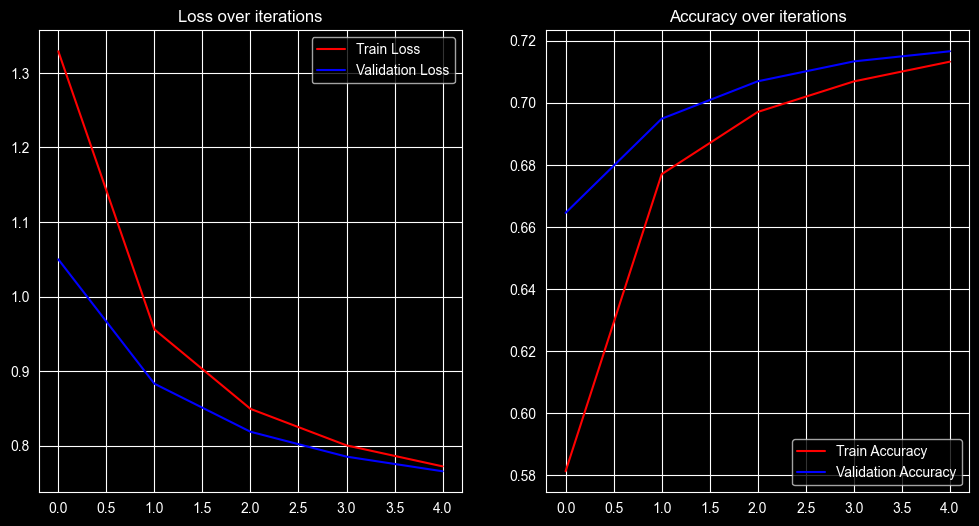

In [110]:
display_metrics(history)

Both training and validation losses keep on decreasing throughout epochs, while both training and validation accuracies grow till last epoch: with 5 epochs the model keeps learning correctly without overfitting. We can also notice that trends are going to plateau but don't do it yet, which means that the training process could appreciate a few more epochs before overfitting, and yield higher performances.

In [111]:
y_pred = tf.squeeze(tf.round(model.predict(X_test, batch_size=batch_size)))
y_test_labels = np.argmax(y_test, axis=-1)
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 63s 461ms/step
              precision    recall  f1-score   support

           0      0.216     0.876     0.346       362
           1      0.828     0.404     0.543       250
           2      0.698     0.575     0.631      1509
           3      0.906     0.872     0.889      1604
           4      0.500     0.011     0.022        90
           5      1.000     0.114     0.204       229
           6      0.669     0.440     0.531      1064

    accuracy                          0.623      5108
   macro avg      0.688     0.470     0.452      5108
weighted avg      0.739     0.623     0.636      5108



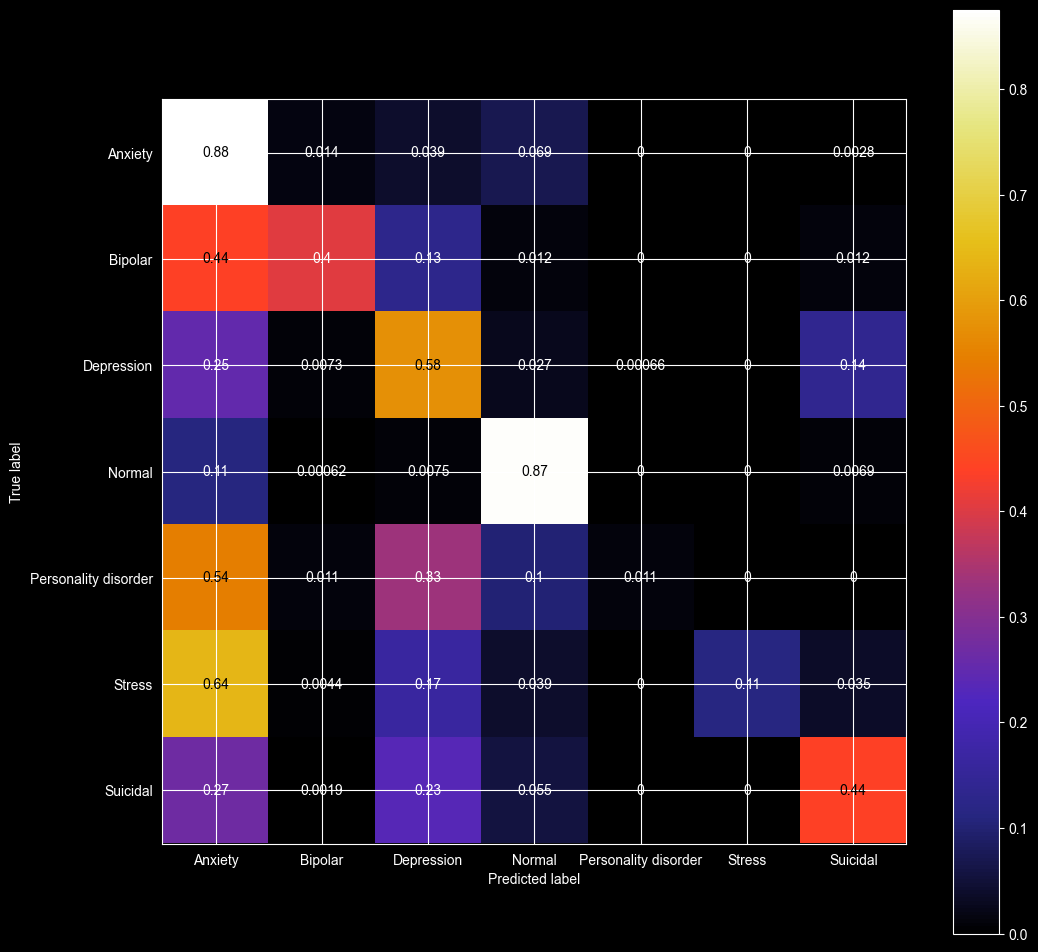

In [112]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

The model does a fairly good job at predicting majority labels such as Normal and Anxiety. But, as expected, the model is not really able to properly label minority groups, especially Personality Disorder and Stress, which get mostly confused as Anxiety.

Resulting weighted F1 score: 0.636

## Trained Models

This time we will learn a word embedding as part of the NN, instead of using a pre-trained one. They'll be built using Keras Sequential methodology.

### Hyperparameters and Vectorization Configuration

A vectorizer layer is required to convert the input text into a vector of integers, which can then be fed to the Embedding layer. I'll train it on the training set before usage.

In [34]:
maxlen = 70                # statements will be truncated/padded at this length before being input to the NN
vocabulary_size = 50000    # used as word embedding dim

vectorizer_layer = TextVectorization(
    max_tokens=vocabulary_size,
    split='whitespace',
    ngrams = None,   # dont group anything, every token alone
    output_mode ='int',
    output_sequence_length=maxlen,
)
vectorizer_layer.adapt(X_train)

### Model #2 - Recurrent Neural Network

RNNs fall in the category of neural networks that maintain some kind of state. They can process sequential data of arbitrary length.

This is the basic RNN, where the output is also fed back as the "hidden state" to the next iteration.

There are two sets of weights, one for the "recurrent" phase and the other for the "kernel" phase. These can be configured separately in terms of their initialization.

In [114]:
model_rnn = tf.keras.Sequential()
model_rnn.add(Input(shape=X_train.shape[1:], dtype=tf.string))
model_rnn.add(vectorizer_layer)
model_rnn.add(Embedding(vocabulary_size, maxlen))
model_rnn.add(SimpleRNN(
    10,
    kernel_initializer=initializers.RandomNormal(stddev=0.001),
    recurrent_initializer=initializers.Identity(gain=1.0),
    activation='relu',
    input_shape=X_train.shape[1:])
)
model_rnn.add(layers.Dense(num_classes, activation='softmax'))
model_rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.summary()

C:\Users\conta\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 70)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_9 (Embedding)         │ (None, 70, 70)         │     3,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │            77 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,500,887 (13.35 MB)

 Trainable params: 3,500,887 (13.35 MB)

 Non-trainable params: 0 (0.00 B)

In [115]:
history = model_rnn.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val))

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 54s 80ms/step - accuracy: 0.6133 - loss: 1.0009 - val_accuracy: 0.6935 - val_loss: 0.8332
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step - accuracy: 0.7139 - loss: 0.7406 - val_accuracy: 0.6905 - val_loss: 0.8111
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step - accuracy: 0.7542 - loss: 0.6473 - val_accuracy: 0.6991 - val_loss: 0.8293
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.7967 - loss: 0.5520 - val_accuracy: 0.7022 - val_loss: 0.8510
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step - accuracy: 0.8239 - loss: 0.4847 - val_accuracy: 0.6882 - val_loss: 0.9438


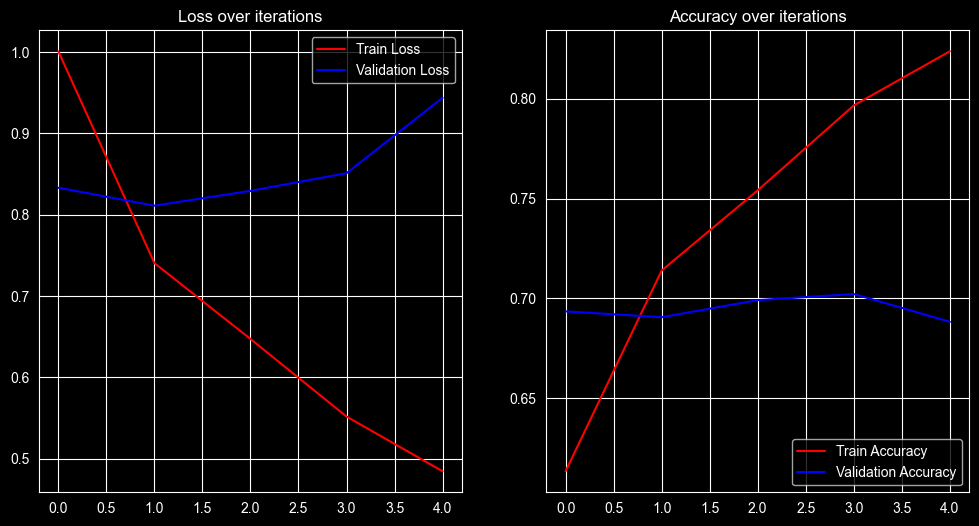

In [116]:
display_metrics(history)

In this case we can notice how the validation loss starts growing already from the 2nd epoch, with the validation accuracy also showing a downward deflection point halfway: this simple model overfits almost immediately, and could appreciate proper regularization for the sake of higher and stabler performance.

In [117]:
y_pred = tf.squeeze(tf.round(model_rnn.predict(X_test, batch_size=batch_size)))
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
              precision    recall  f1-score   support

           0      0.411     0.710     0.521       362
           1      0.865     0.588     0.700       250
           2      0.571     0.734     0.642      1509
           3      0.917     0.887     0.902      1604
           4      0.000     0.000     0.000        90
           5      0.462     0.288     0.355       229
           6      0.642     0.409     0.499      1064

    accuracy                          0.672      5108
   macro avg      0.552     0.517     0.517      5108
weighted avg      0.682     0.672     0.664      5108



C:\Users\conta\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\conta\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\conta\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


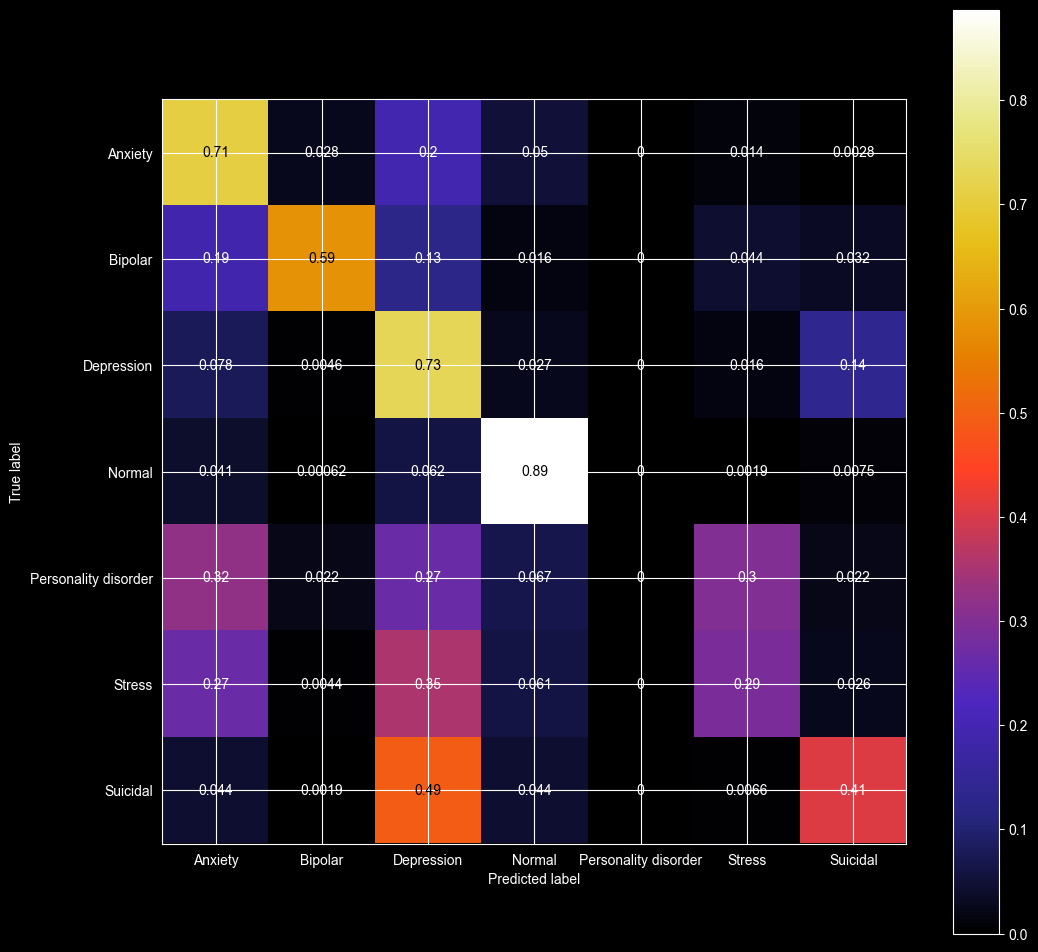

In [118]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

Despite overfitting, the resulting weighted F1 score is still higher previous model's score: 0.664. This can be considered an indicator of the superiority of RNN-based approaches compared with standard NNs when dealing with sequential data. Still, we can observe that in this case the Personality Disorder class gets fully mismatched.

### Model #3 - Long-Short Term Memory

An LSTM cell has a complex internal structure that makes it able to:

* learn to recognize an important input,
* store it in the long-term state,
* preserve it for as long as it is needed,
* extract it whenever it is needed.

In [119]:
model_lstm = tf.keras.Sequential()
model_lstm.add(Input(shape=X_train.shape[1:], dtype=tf.string))
model_lstm.add(vectorizer_layer)
model_lstm.add(Embedding(vocabulary_size, maxlen))
model_lstm.add(LSTM(50, input_shape=(maxlen, vocabulary_size)))
model_lstm.add(layers.Dense(num_classes, activation='softmax'))
model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.summary()

C:\Users\conta\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 70)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_10 (Embedding)        │ (None, 70, 70)         │     3,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        24,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,524,557 (13.45 MB)

 Trainable params: 3,524,557 (13.45 MB)

 Non-trainable params: 0 (0.00 B)

In [120]:
history = model_lstm.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val))

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 88s 138ms/step - accuracy: 0.4914 - loss: 1.3495 - val_accuracy: 0.5568 - val_loss: 1.2063
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 75s 131ms/step - accuracy: 0.5670 - loss: 1.1216 - val_accuracy: 0.5847 - val_loss: 1.0190
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 76s 131ms/step - accuracy: 0.5870 - loss: 0.9845 - val_accuracy: 0.6025 - val_loss: 0.9738
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 76s 131ms/step - accuracy: 0.6375 - loss: 0.8588 - val_accuracy: 0.6349 - val_loss: 0.9029
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 74s 129ms/step - accuracy: 0.7016 - loss: 0.7398 - val_accuracy: 0.6769 - val_loss: 0.8558


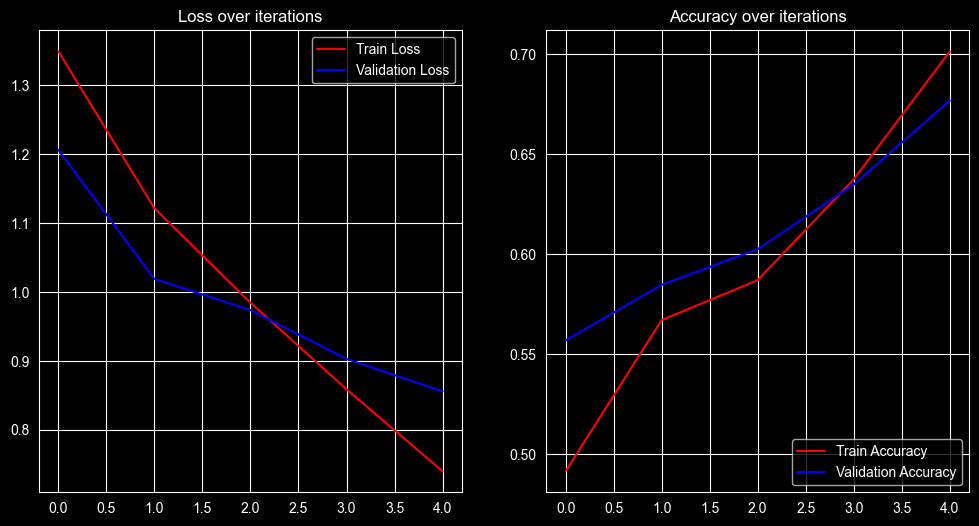

In [121]:
display_metrics(history)

As with model #1, also in this case the training process proceeds well, with validation accuracy steadily growing till last epoch, almost to 0.7. We can actually observe a steeper curve than model #1's validation accuracy curve, an indicator of probably better performances than previous models if processed for more training epochs. Still, we can also observe that the trend starts at a significantly lower performance (0.55) than previous models'.

In [122]:
y_pred = tf.squeeze(tf.round(model_lstm.predict(X_test, batch_size=batch_size)))
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step
              precision    recall  f1-score   support

           0      0.286     0.732     0.412       362
           1      0.548     0.368     0.440       250
           2      0.616     0.602     0.609      1509
           3      0.908     0.865     0.886      1604
           4      0.000     0.000     0.000        90
           5      0.000     0.000     0.000       229
           6      0.612     0.584     0.598      1064

    accuracy                          0.641      5108
   macro avg      0.424     0.450     0.421      5108
weighted avg      0.642     0.641     0.633      5108



C:\Users\conta\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\conta\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\conta\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


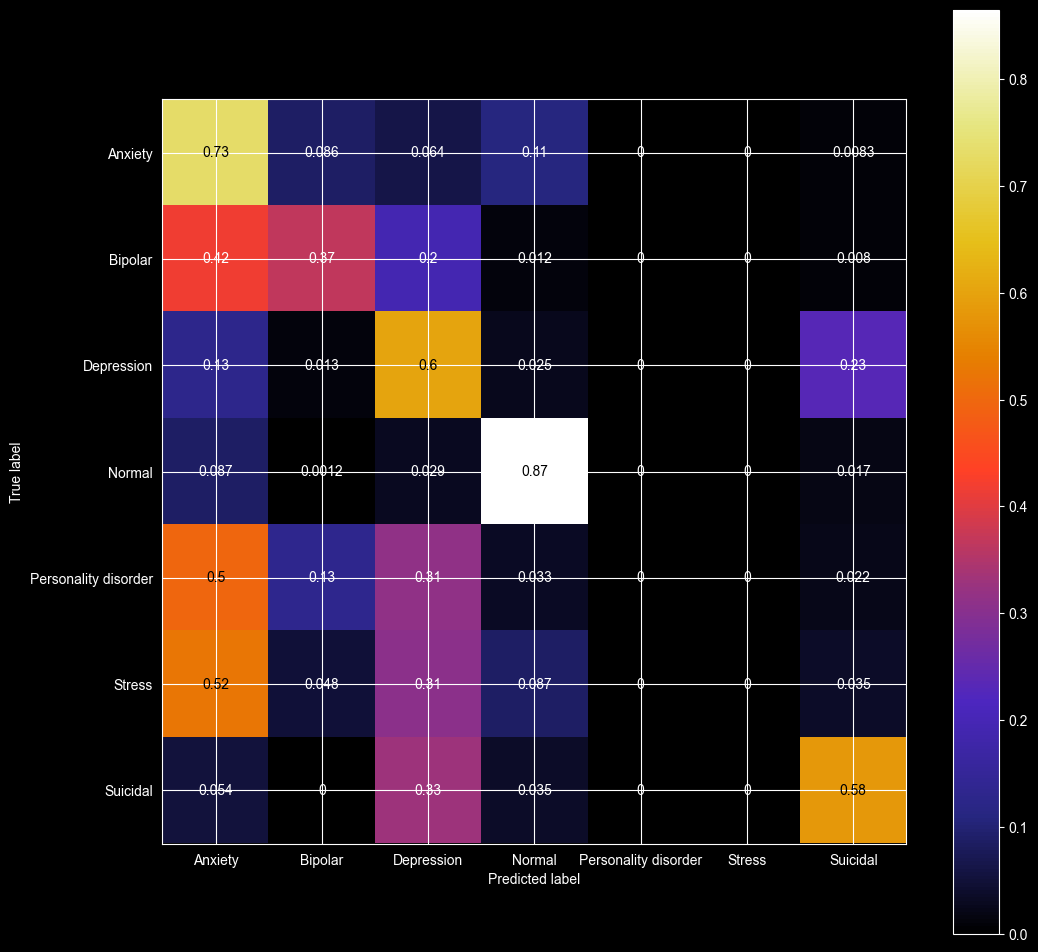

In [123]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

The resulting weighted F1 score (0.633) is the lowest among tested models, and despite the non-overfitting steep trend, we can still notice that the applied training epochs were too few to properly train this complex model. Also, the LSTM can't catch any sample from the 2 minority classes (Personality Disorder and Stress).

### Model #4 - Gated Recurrent Unit

GRU is a simplification of the LSTM cell that performs similarly well while being faster to train. It has a single update gate controller that manages both the forget and input gates. Whenever one is open, the other is closed. There is no output gate. The reset gate controls which part of the previous state is shown to the main layer. The resulting model is simpler than standard LSTM models. GRUs have fewer parameters and thus may train a bit faster or need less data to generalize.

In [124]:
model_gru = tf.keras.Sequential()
model_gru.add(Input(shape=X_train.shape[1:], dtype=tf.string))
model_gru.add(vectorizer_layer)
model_gru.add(Embedding(vocabulary_size, maxlen))
model_gru.add(GRU(50, input_shape=(maxlen, vocabulary_size)))
model_gru.add(layers.Dense(num_classes, activation='softmax'))
model_gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_gru.summary()

C:\Users\conta\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 70)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_11 (Embedding)        │ (None, 70, 70)         │     3,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 50)             │        18,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,518,657 (13.42 MB)

 Trainable params: 3,518,657 (13.42 MB)

 Non-trainable params: 0 (0.00 B)

In [125]:
history = model_gru.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val))

Epoch 1/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 91s 142ms/step - accuracy: 0.5640 - loss: 1.1285 - val_accuracy: 0.6755 - val_loss: 0.8435
Epoch 2/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 80s 139ms/step - accuracy: 0.7134 - loss: 0.7381 - val_accuracy: 0.7275 - val_loss: 0.7307
Epoch 3/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 81s 141ms/step - accuracy: 0.7853 - loss: 0.5677 - val_accuracy: 0.7345 - val_loss: 0.7162
Epoch 4/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 80s 140ms/step - accuracy: 0.8379 - loss: 0.4421 - val_accuracy: 0.7309 - val_loss: 0.7659
Epoch 5/5
575/575 ━━━━━━━━━━━━━━━━━━━━ 80s 139ms/step - accuracy: 0.8801 - loss: 0.3376 - val_accuracy: 0.7160 - val_loss: 0.8605


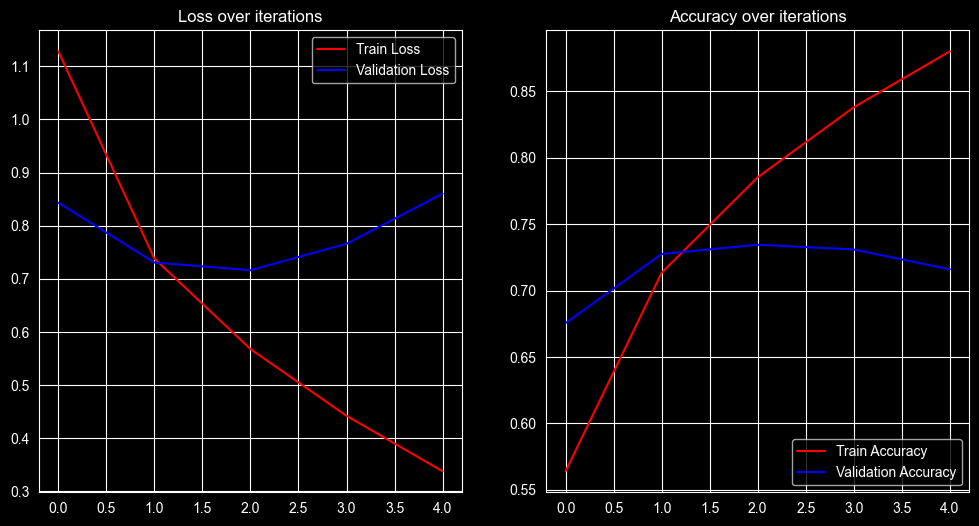

In [126]:
display_metrics(history)

Validation loss and accuracy for model #4 show a light downward inflection point, suggesting that the model is slowly overfitting. We can still observe more stability with respect to previous models' trends.

In [127]:
y_pred = tf.squeeze(tf.round(model_gru.predict(X_test, batch_size=batch_size)))
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step
              precision    recall  f1-score   support

           0      0.459     0.793     0.582       362
           1      0.861     0.644     0.737       250
           2      0.633     0.678     0.655      1509
           3      0.933     0.842     0.885      1604
           4      0.923     0.267     0.414        90
           5      0.453     0.297     0.359       229
           6      0.614     0.610     0.612      1064

    accuracy                          0.697      5108
   macro avg      0.697     0.590     0.606      5108
weighted avg      0.719     0.697     0.699      5108



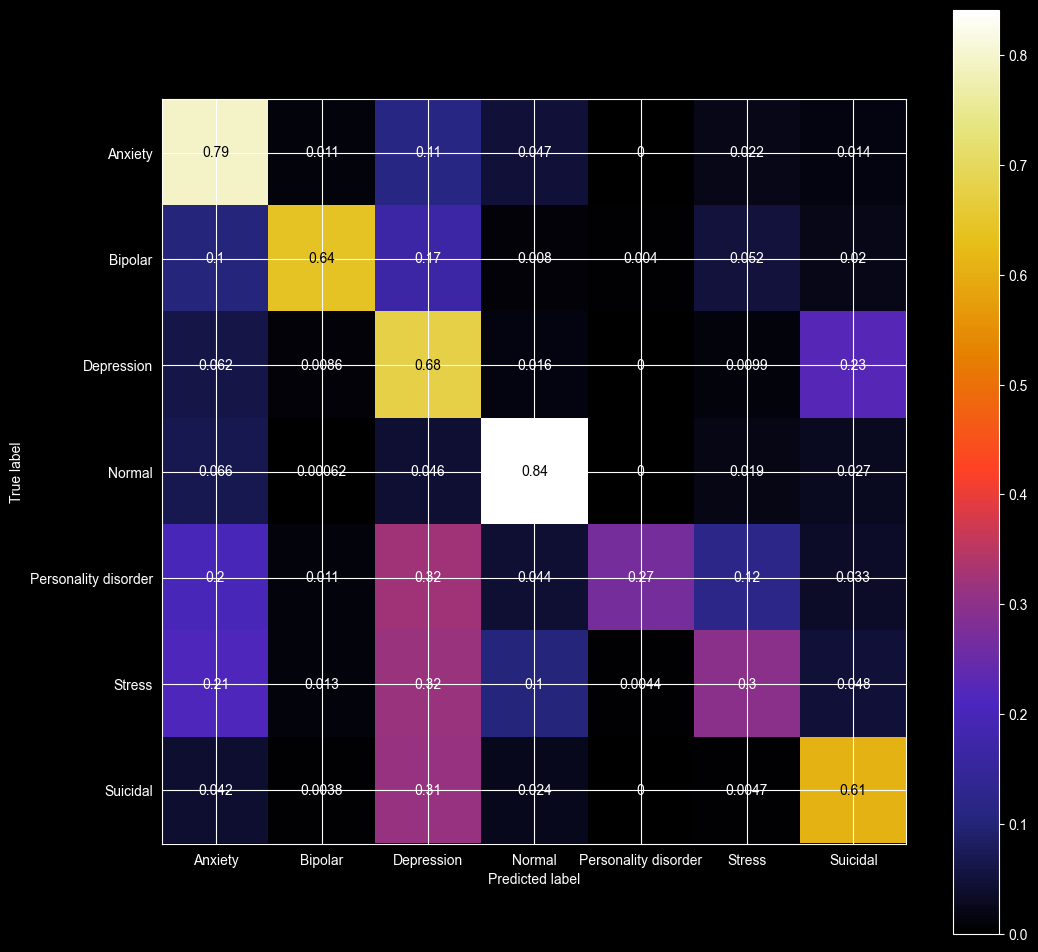

In [128]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

Classification report and confusion matrix show this model as the winner after only 5 iterations, despite slightly overfitting: we got the highest weighted F1 score (0.699) together with the ability to partially catch minority classes samples.

Let's chose this model as the final one and proceed with its regularization.

## Model Selection and Regularization

Now that we selected the winner model, let's raise the number of epochs to ensure a deeper and more effective regularization process.

### Regularization Iteration #1

Let's add some Batch Normalization layers among relevant NN layers.

Batch normalization is a technique for training deep NNs that normalizes the inputs to a layer for every mini-batch.
* It stabilizes the learning process;
* it addresses the internal covariate shift problem.

In [129]:
n_epochs = 10

model_gru_1 = tf.keras.Sequential()
model_gru_1.add(Input(shape=X_train.shape[1:], dtype=tf.string))
model_gru_1.add(vectorizer_layer)
model_gru_1.add(Embedding(vocabulary_size, maxlen))
model_gru_1.add(BatchNormalization())
model_gru_1.add(GRU(50, input_shape=(maxlen, vocabulary_size)))
model_gru_1.add(BatchNormalization())
model_gru_1.add(layers.Dense(num_classes, activation='softmax'))
model_gru_1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_gru_1.summary()

C:\Users\conta\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 70)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (None, 70, 70)         │     3,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 70, 70)         │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 50)             │        18,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,519,137 (13.42 MB)

 Trainable params: 3,518,897 (13.42 MB)

 Non-trainable params: 240 (960.00 B)

In [130]:
history = model_gru_1.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val))

Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 102s 152ms/step - accuracy: 0.5508 - loss: 1.1975 - val_accuracy: 0.6232 - val_loss: 1.0400
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 84s 146ms/step - accuracy: 0.7456 - loss: 0.6688 - val_accuracy: 0.7290 - val_loss: 0.7221
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 86s 149ms/step - accuracy: 0.8441 - loss: 0.4282 - val_accuracy: 0.7159 - val_loss: 0.8194
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - accuracy: 0.9069 - loss: 0.2697 - val_accuracy: 0.7171 - val_loss: 0.9095
Epoch 5/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 83s 144ms/step - accuracy: 0.9421 - loss: 0.1720 - val_accuracy: 0.7197 - val_loss: 1.0369
Epoch 6/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 85s 148ms/step - accuracy: 0.9636 - loss: 0.1130 - val_accuracy: 0.6943 - val_loss: 1.2115
Epoch 7/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 84s 146ms/step - accuracy: 0.9772 - loss: 0.0758 - val_accuracy: 0.7170 - val_loss: 1.2974
Epoch 8/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - accuracy: 0.9829 - loss: 

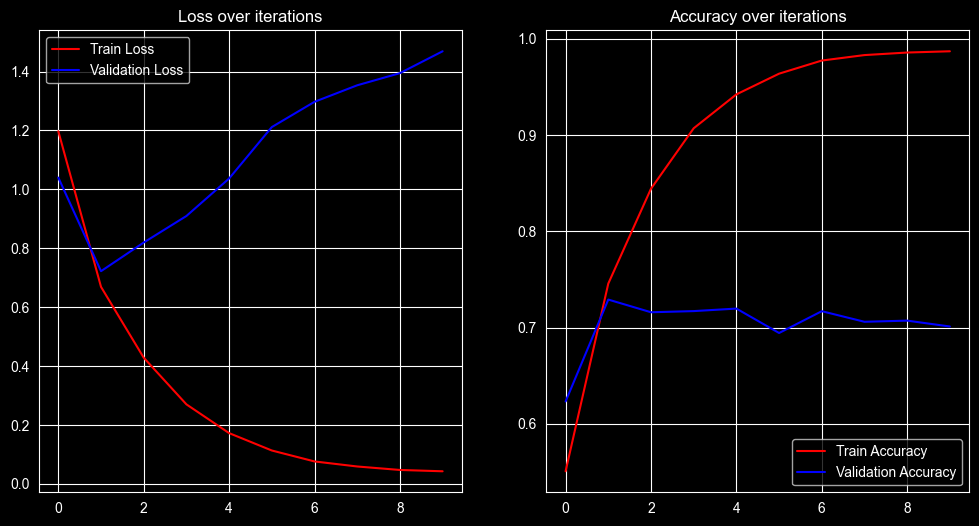

In [131]:
display_metrics(history)

Validation accuracy doesn't improve throughout generations, and we can notice how the validation loss starts growing at the second epoch: this first iteration is not enough to adequately regularize the model.

In [132]:
y_pred = tf.squeeze(tf.round(model_gru_1.predict(X_test, batch_size=batch_size)))
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step
              precision    recall  f1-score   support

           0      0.634     0.693     0.662       362
           1      0.663     0.700     0.681       250
           2      0.641     0.577     0.608      1509
           3      0.896     0.883     0.890      1604
           4      0.565     0.433     0.491        90
           5      0.386     0.397     0.391       229
           6      0.549     0.620     0.582      1064

    accuracy                          0.686      5108
   macro avg      0.619     0.615     0.615      5108
weighted avg      0.690     0.686     0.687      5108



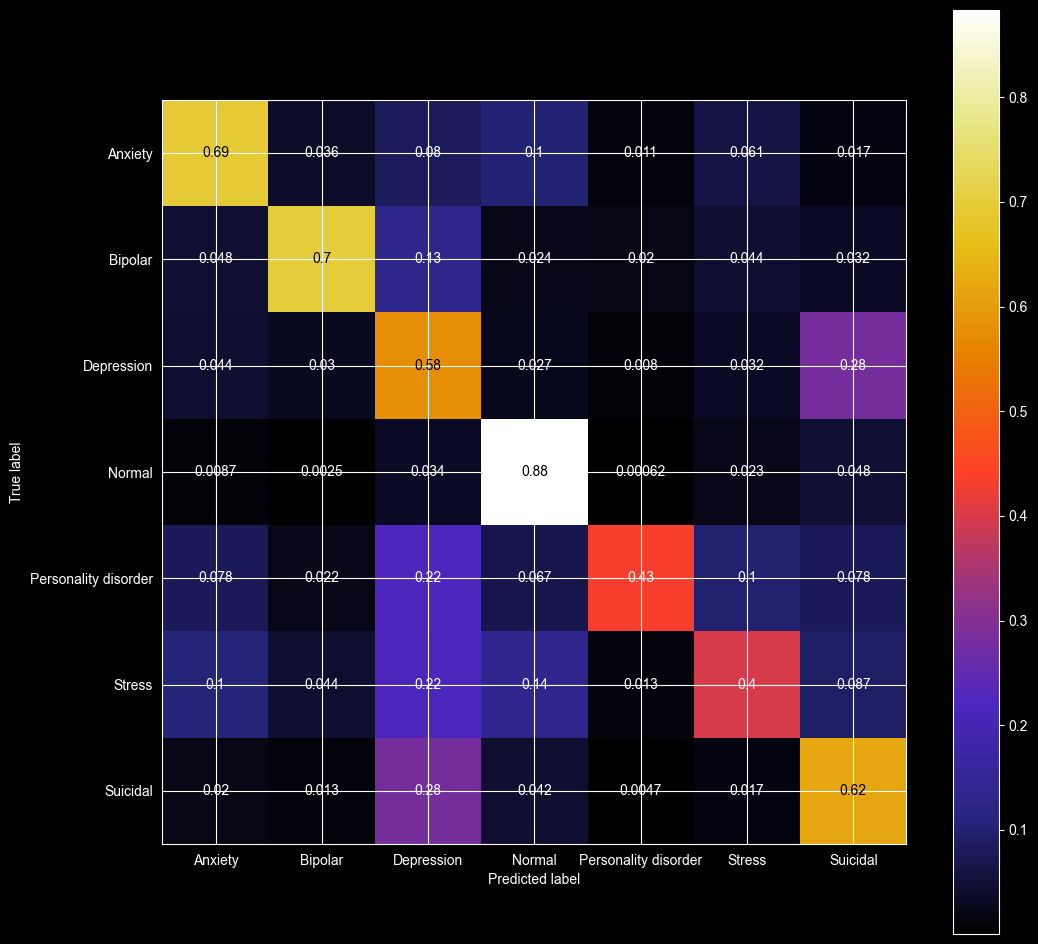

In [133]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

Addition of Batch Normalization layers didn't help - the model shows a slightly worse case of overfitting than before. Also, results after 10 epochs are worse than the previous ones, with a weighted F1 score of 0.687. On the other hand, we can notice how the model has improved in the classification of minority class samples.

### Regularization Iteration #2

Let's add some Dropout layers among relevant NN layers.

At each training iteration (batch) we randomly remove a subset of neurons.
* This prevents the NN from relying too much on individual pathways, and makes the NN more robust.
* At test time we rescale the weights to reflect the percentage of time it was active: if the neuron was present with a probability P then weights will be scaled by a factor of P.

In [134]:
model_gru_2 = tf.keras.Sequential()
model_gru_2.add(Input(shape=X_train.shape[1:], dtype=tf.string))
model_gru_2.add(vectorizer_layer)
model_gru_2.add(Embedding(vocabulary_size, maxlen))
model_gru_2.add(BatchNormalization())
model_gru_2.add(Dropout(rate=0.4, seed=42))
model_gru_2.add(BatchNormalization())
model_gru_2.add(GRU(50, input_shape=(maxlen, vocabulary_size)))
model_gru_2.add(BatchNormalization())
model_gru_2.add(Dropout(rate=0.4, seed=42))
model_gru_2.add(BatchNormalization())
model_gru_2.add(layers.Dense(num_classes, activation='softmax'))
model_gru_2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_gru_2.summary()

C:\Users\conta\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 70)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_13 (Embedding)        │ (None, 70, 70)         │     3,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 70, 70)         │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 70, 70)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 70, 70)         │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 50)             │        18,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,519,617 (13.43 MB)

 Trainable params: 3,519,137 (13.42 MB)

 Non-trainable params: 480 (1.88 KB)

In [135]:
history = model_gru_2.fit(x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val))

Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 120s 180ms/step - accuracy: 0.4585 - loss: 1.5260 - val_accuracy: 0.5547 - val_loss: 1.3167
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 104s 181ms/step - accuracy: 0.5911 - loss: 1.0400 - val_accuracy: 0.6465 - val_loss: 0.9421
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 93s 162ms/step - accuracy: 0.7205 - loss: 0.7361 - val_accuracy: 0.7382 - val_loss: 0.7110
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 92s 160ms/step - accuracy: 0.7835 - loss: 0.5775 - val_accuracy: 0.7532 - val_loss: 0.6769
Epoch 5/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 94s 164ms/step - accuracy: 0.8271 - loss: 0.4678 - val_accuracy: 0.7312 - val_loss: 0.7532
Epoch 6/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 93s 162ms/step - accuracy: 0.8619 - loss: 0.3818 - val_accuracy: 0.7217 - val_loss: 0.8400
Epoch 7/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 92s 159ms/step - accuracy: 0.8856 - loss: 0.3167 - val_accuracy: 0.7184 - val_loss: 0.8855
Epoch 8/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 95s 165ms/step - accuracy: 0.9032 - loss:

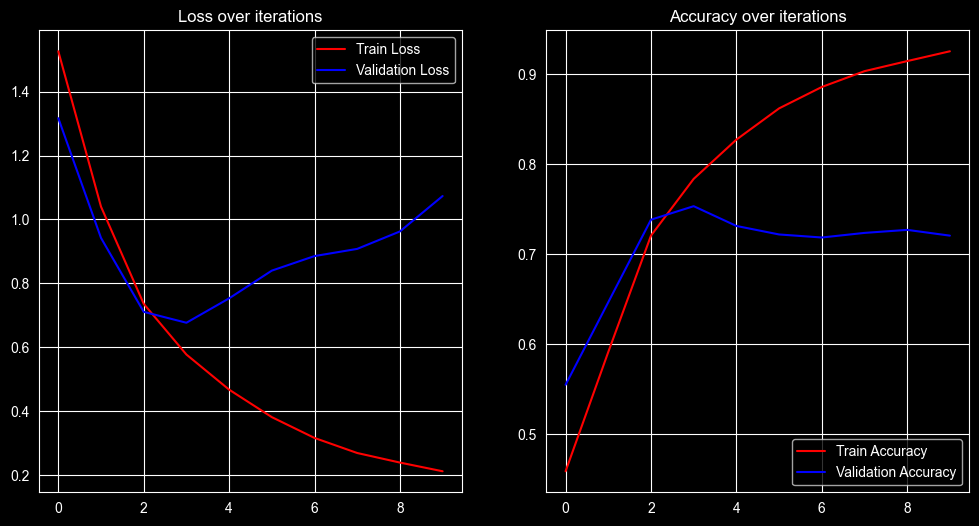

In [136]:
display_metrics(history)

We can still notice an overfitting pattern, but this time is delayed and characterized by milder curves with respect to the previous iteration.

In [137]:
y_pred = tf.squeeze(tf.round(model_gru_2.predict(X_test, batch_size=batch_size)))
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step
              precision    recall  f1-score   support

           0      0.544     0.787     0.643       362
           1      0.771     0.700     0.734       250
           2      0.715     0.559     0.627      1509
           3      0.918     0.903     0.911      1604
           4      0.592     0.500     0.542        90
           5      0.528     0.410     0.462       229
           6      0.555     0.702     0.620      1064

    accuracy                          0.712      5108
   macro avg      0.660     0.652     0.648      5108
weighted avg      0.726     0.712     0.712      5108



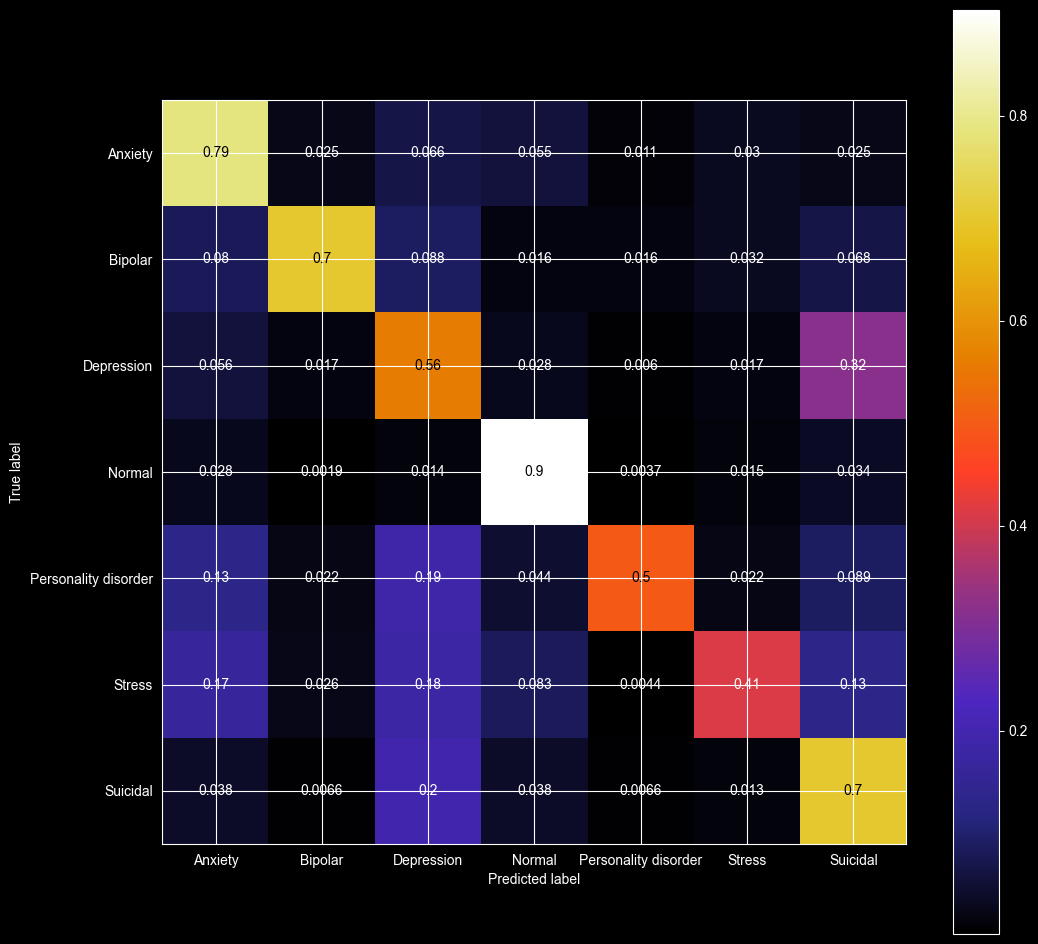

In [138]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

We achieved a higher score with respect to the model's performance before regularization: 0.712. Dropout confirmed as effective regularization strategy for this problem and model.

### Regularization Iteration #3

Let's raise dropout rate.

In [187]:
model_gru_3 = tf.keras.Sequential()
model_gru_3.add(Input(shape=X_train.shape[1:], dtype=tf.string))
model_gru_3.add(vectorizer_layer)
model_gru_3.add(Embedding(vocabulary_size, maxlen))
model_gru_3.add(BatchNormalization())
model_gru_3.add(Dropout(rate=0.6, seed=42))
model_gru_3.add(BatchNormalization())
model_gru_3.add(GRU(50, input_shape=(maxlen, vocabulary_size)))
model_gru_3.add(BatchNormalization())
model_gru_3.add(Dropout(rate=0.6, seed=42))
model_gru_3.add(BatchNormalization())
model_gru_3.add(layers.Dense(num_classes, activation='softmax'))
model_gru_3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_gru_3.summary()

C:\Users\conta\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 70)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_24 (Embedding)        │ (None, 70, 70)         │     3,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 70, 70)         │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 70, 70)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 70, 70)         │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_19 (GRU)                    │ (None, 50)             │        18,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,519,617 (13.43 MB)

 Trainable params: 3,519,137 (13.42 MB)

 Non-trainable params: 480 (1.88 KB)

In [188]:
history = model_gru_3.fit(
    x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val)
)

Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 123s 172ms/step - accuracy: 0.4402 - loss: 1.5648 - val_accuracy: 0.5566 - val_loss: 1.3896
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 142s 172ms/step - accuracy: 0.5682 - loss: 1.0907 - val_accuracy: 0.5978 - val_loss: 0.9630
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 91s 158ms/step - accuracy: 0.6239 - loss: 0.9007 - val_accuracy: 0.6675 - val_loss: 0.8511
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 93s 162ms/step - accuracy: 0.6877 - loss: 0.7905 - val_accuracy: 0.7109 - val_loss: 0.8050
Epoch 5/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 91s 158ms/step - accuracy: 0.7345 - loss: 0.7051 - val_accuracy: 0.7186 - val_loss: 0.8012
Epoch 6/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 92s 160ms/step - accuracy: 0.7670 - loss: 0.6366 - val_accuracy: 0.7067 - val_loss: 0.8221
Epoch 7/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 94s 164ms/step - accuracy: 0.7965 - loss: 0.5676 - val_accuracy: 0.7272 - val_loss: 0.7793
Epoch 8/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 95s 166ms/step - accuracy: 0.8163 - loss:

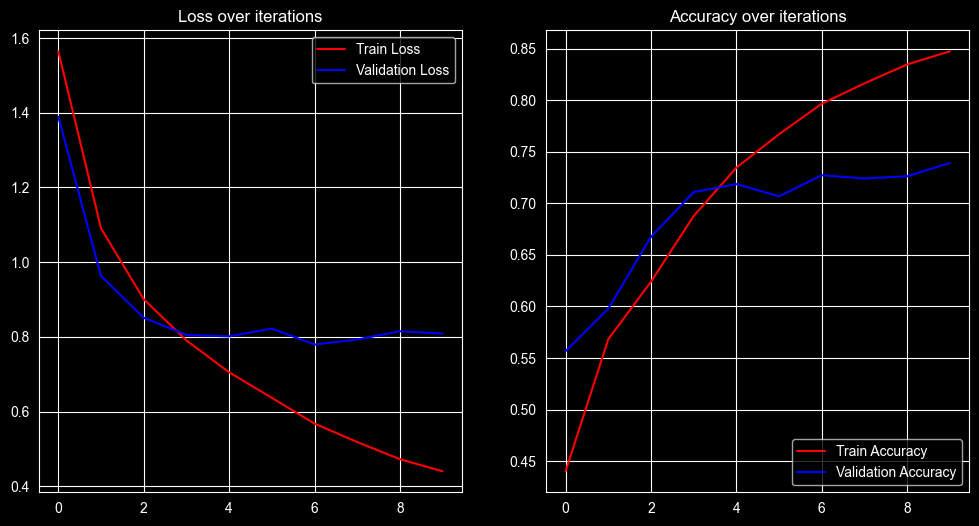

In [189]:
display_metrics(history)

Raising dropout impact resulted in a stabler training process: validation loss stabilizes at 0.8 and validation accuracy keeps improving throughout the epochs.

In [190]:
y_pred = tf.squeeze(tf.round(model_gru_3.predict(X_test, batch_size=batch_size)))
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step
              precision    recall  f1-score   support

           0      0.472     0.818     0.599       362
           1      0.856     0.692     0.765       250
           2      0.658     0.670     0.664      1509
           3      0.922     0.899     0.910      1604
           4      1.000     0.122     0.218        90
           5      0.657     0.310     0.421       229
           6      0.602     0.600     0.601      1064

    accuracy                          0.713      5108
   macro avg      0.738     0.587     0.597      5108
weighted avg      0.732     0.713     0.710      5108



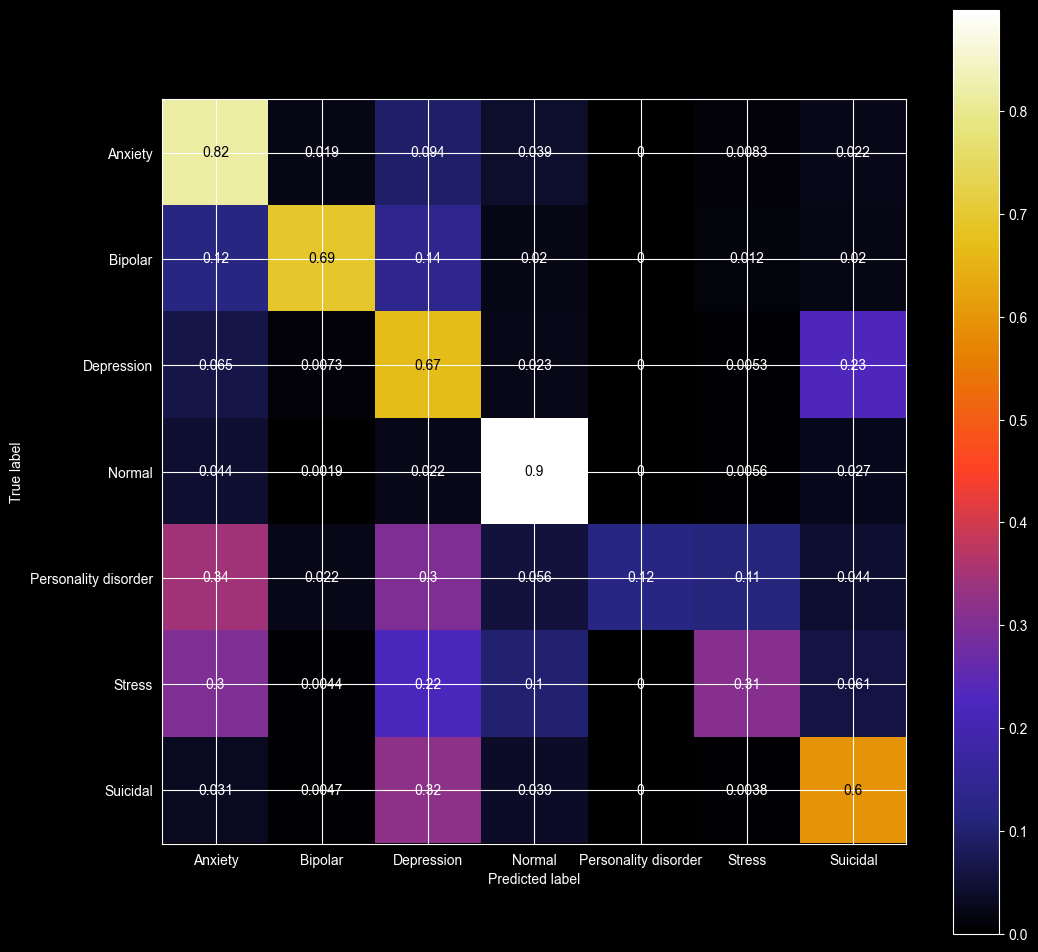

In [191]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

We obtained a weighted F1 score of 0.71, basically the same as previous iteration, with the advantage of a stabler training process. Still, it can be observed how the model can't predict well on samples from the minority classes.

### Iteration #4 - Class Weighing

In this iteration let us apply class weighing to possibly improve minority classes classification.

In [39]:
model_gru_4 = tf.keras.Sequential()
model_gru_4.add(Input(shape=X_train.shape[1:], dtype=tf.string))
model_gru_4.add(vectorizer_layer)
model_gru_4.add(Embedding(vocabulary_size, maxlen))
model_gru_4.add(BatchNormalization())
model_gru_4.add(Dropout(rate=0.6, seed=42))
model_gru_4.add(BatchNormalization())
model_gru_4.add(GRU(50, input_shape=(maxlen, vocabulary_size)))
model_gru_4.add(BatchNormalization())
model_gru_4.add(Dropout(rate=0.6, seed=42))
model_gru_4.add(BatchNormalization())
model_gru_4.add(layers.Dense(num_classes, activation='softmax'))
model_gru_4.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model_gru_4.summary()

C:\Users\conta\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 70)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 70, 70)         │     3,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 70, 70)         │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 70, 70)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 70, 70)         │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 50)             │        18,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,519,617 (13.43 MB)

 Trainable params: 3,519,137 (13.42 MB)

 Non-trainable params: 480 (1.88 KB)

In [43]:
y_train_labels = np.argmax(y_train, axis=-1)
classes = [0,1,2,3,4,5,6]
class_weight = compute_class_weight('balanced', y=y_train_labels, classes=np.array(classes))
class_weight = {k: float(v) for k, v in zip(classes, class_weight)}
print(class_weight)

history = model_gru_4.fit(
    x=X_train, y=y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_val, y_val), class_weight=class_weight,
)

{0: 2.0172811059907834, 1: 2.9167129372570795, 2: 0.48365712181198783, 3: 0.45488396259092484, 4: 8.156832298136646, 5: 3.1817080557238038, 6: 0.6855912294440094}
Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 95s 165ms/step - accuracy: 0.3632 - loss: 1.8131 - val_accuracy: 0.3183 - val_loss: 1.5638
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 89s 154ms/step - accuracy: 0.4517 - loss: 1.5553 - val_accuracy: 0.5764 - val_loss: 1.1332
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 89s 154ms/step - accuracy: 0.5774 - loss: 1.2106 - val_accuracy: 0.6167 - val_loss: 1.0205
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 88s 153ms/step - accuracy: 0.6265 - loss: 0.9481 - val_accuracy: 0.6557 - val_loss: 0.8515
Epoch 5/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 89s 154ms/step - accuracy: 0.6674 - loss: 0.7977 - val_accuracy: 0.6686 - val_loss: 0.8796
Epoch 6/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 92s 160ms/step - accuracy: 0.7037 - loss: 0.6781 - val_accuracy: 0.6949 - val_loss: 0.7883
Epoch 7/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 88s 152ms/s

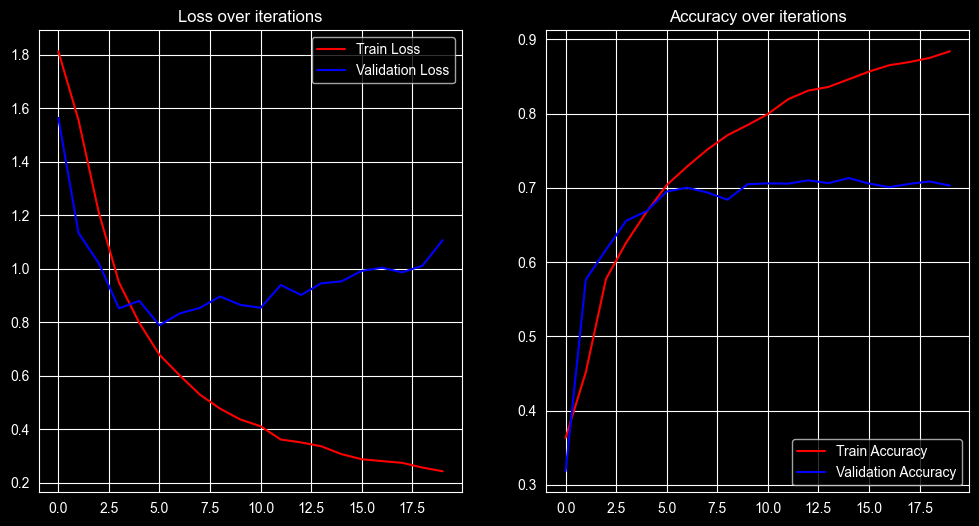

In [44]:
display_metrics(history)

Validation loss and accuracy present slightly worse trends with respect to the previous iteration, indicating the more difficult convergence associated with class weighing applied to an unbalanced classification problem.

In [47]:
y_pred = tf.squeeze(tf.round(model_gru_4.predict(X_test, batch_size=batch_size)))
y_pred_labels = np.argmax(y_pred, axis=-1)

print(classification_report(y_test_labels, y_pred_labels, digits=3))

80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
              precision    recall  f1-score   support

           0      0.530     0.801     0.638       362
           1      0.762     0.732     0.747       250
           2      0.735     0.504     0.598      1509
           3      0.926     0.875     0.900      1604
           4      0.385     0.611     0.472        90
           5      0.412     0.493     0.449       229
           6      0.555     0.705     0.621      1064

    accuracy                          0.696      5108
   macro avg      0.615     0.675     0.632      5108
weighted avg      0.723     0.696     0.699      5108



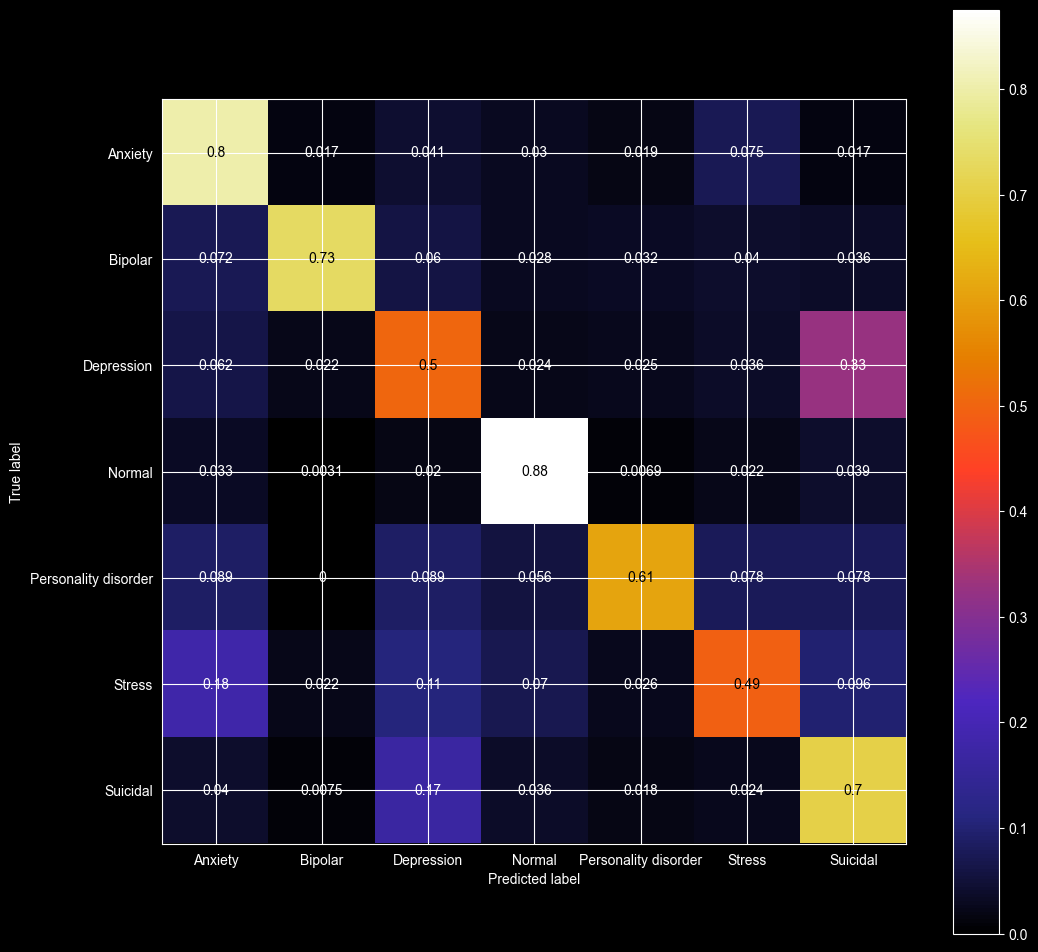

In [48]:
fig, ax = plt.subplots(figsize=(12, 12))
cf = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=label_encoder.categories_[0])
disp.plot(cmap='CMRmap', ax=ax);

Resulting weighted F1 score is slightly worse than previous iteration, with the advantage of more balanced classification results across all classes. For instance, the detection of the first minority class, Personality Disorder, improved from a recall value of 0.12 to 0.61.

# Conclusions and next steps

The target mental health dataset was cleaned and preprocessed so as to be fed as input to a series of Deep Learning NLP models, and the Gated Recurrent Unit model resulted as the best-performing one for the task at hand. The winner model was then regularized and trained for an extended number of epochs, which finally brought to higher classification performances.

Other regularization approaches could be attempted for a stabler training procedure, such as Lasso or Ridge applied to Dense and/or GRU layers, or training data shuffling at each epoch.

Copyright @ IBM Corporation. All rights reserved.
